In [ ]:
%%writefile ./endpoint.yaml
$schema: https://azuremlschemas.azureedge.net/latest/managedOnlineEndpoint.schema.json
name: AllRecipeEndpoint
auth_mode: key

In [ ]:
!az ml online-endpoint create --file ./endpoint.yaml

In [ ]:
%%writefile ./deployment.yaml
$schema: https://azuremlschemas.azureedge.net/latest/managedOnlineDeployment.schema.json
name: blue
endpoint_name: AllRecipeEndpoint
model: azureml:phi3_finetuned_allrecipes@latest
code_configuration:
  code: .
  scoring_script: score_allrecipes.py
environment: azureml:phi35vision@latest
instance_type: Standard_NC12s_v3
instance_count: 1
request_settings:
  request_timeout_ms: 180000

In [ ]:
!az ml online-deployment create --all-traffic --file ./deployment.yaml

# Test the Deployment

In [1]:
import urllib.request
import json
import os
import ssl
from score_allrecipes import process_actions_string, image_to_data_url, load_image

# Replace this with the primary/secondary key, AMLToken, or Microsoft Entra ID token for the endpoint
api_key = 'dwgHkNprbQ8YJeq3YSN5mTrfoatcM2p4'
url = 'https://allrecipeendpoint.northeurope.inference.ml.azure.com/score'

def allowSelfSignedHttps(allowed):
    # bypass the server certificate verification on client side
    if allowed and not os.environ.get('PYTHONHTTPSVERIFY', '') and getattr(ssl, '_create_unverified_context', None):
        ssl._create_default_https_context = ssl._create_unverified_context

allowSelfSignedHttps(True) # this line is needed if you use self-signed certificate in your scoring service.

images_root_dir = "C:\\Users\\antonslutsky\\Dev\\azureml-quickstart\\slm-finetuning\\phi3-vision-finetune\\applications\\AllrecipesAgent\\output\\session_2024-09-01_13-44-04\\images"
images_ext = ".png"

def local_image_loader(local_image_name):
    return load_image(f"{images_root_dir}\\{local_image_name}{images_ext}")

def local_image_action_updater(image, img_cnt, actions_image_url):
    image = local_image_loader(actions_image_url)
    return image_to_data_url(image, images_ext)


def test_slm(prompt = "You are a useful AI that searches AllRecipes.com website for various recipies.  The following document contains a set of keyboard and mouth actions together with the screenshots that preempted them to search for 'mashed potatoes' recipe on the website.  Suggest the nest set of keyboard and mouth actions to continue searching for the recipe. ['<sleep>11.645689', '<image>screenshot_2024-09-01_13-44-26.624344', 'mashed']",
             ):

    action_string, images = process_actions_string(prompt, 
                                                   image_loader=local_image_loader,
                                                   action_updater=local_image_action_updater)
    
    action_string = action_string.replace("<|end|><|assistant|>", "").replace("data:image/png;base64", "data:image/jpeg;base64")

    with open("test_out.txt", "w") as test_out:
        test_out.write(action_string)

    data = {"input_data": {"input_string": [
            action_string
    ]}}
    
    #print("action_string:", action_string)

    body = str.encode(json.dumps(data))
    # print("body:", body)

    if not api_key:
        raise Exception("A key should be provided to invoke the endpoint")

    headers = {'Content-Type':'application/json', 'Authorization':('Bearer '+ api_key), 'azureml-model-deployment': 'blue' }

    if True:
        req = urllib.request.Request(url, body, headers)

        try:
            print("------------------------------------")
            response = urllib.request.urlopen(req)

            
            result = response.read()

            steps_response = result.decode("utf-8")
            print(steps_response)
            
            steps_response = json.loads(steps_response)
            steps_response = steps_response[0]["0"]
            steps_response = steps_response.replace(">]", ">\"]")
            while steps_response.startswith("\\"):
                steps_response = steps_response[1:]
            
            steps_response = steps_response.replace("\'", "\"")

            print("1", steps_response, len(steps_response))
            steps_response = json.loads(steps_response)
            print("2",steps_response, len(steps_response))

            print("=====================================")
            return steps_response
        except urllib.error.HTTPError as error:
            print("The request failed with status code: " + str(error.code))

            # Print the headers - they include the requert ID and the timestamp, which are useful for debugging the failure
            print(error.info())
            print(error.read().decode("utf8", 'ignore'))


test_slm()

c:\Users\antonslutsky\AppData\Local\anaconda3\envs\many_models\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


----------------------------------
INPUT_STRING: You are a useful AI that searches AllRecipes.com website for various recipies.  The following document contains a set of keyboard and mouth actions together with the screenshots that preempted them to search for 'mashed potatoes' recipe on the website.  Suggest the nest set of keyboard and mouth actions to continue searching for the recipe. ['<sleep>11.645689', '<image>screenshot_2024-09-01_13-44-26.624344', 'mashed']
----------------------------------
------------------------------------
[{"0": "[\"<sleep>11.645689\", \"<image>]"}]
1 ["<sleep>11.645689", "<image>"] 31
2 ['<sleep>11.645689', '<image>'] 2


['<sleep>11.645689', '<image>']

In [2]:
import threading
import time
import datetime

import shutil

import pyautogui

from pynput.keyboard import Key, Listener
from pynput import mouse 
import logging
import os
from win32gui import GetWindowText, GetForegroundWindow



output_dir = images_root_dir
print("output_dir", output_dir)

os.makedirs(output_dir, exist_ok=True)

images_dir = output_dir
# images_dir = f"{output_dir}/images"
# os.makedirs(images_dir, exist_ok=True)

def capture_screenshot(key, out_dir = images_dir):
    # Capture the screenshot
    screenshot = pyautogui.screenshot()

    file_name = f"screenshot_{key}"
    output_file = f"{out_dir}/{file_name}.png"
    # Save the screenshot
    screenshot.save(output_file)
    return file_name, output_file

capture_screenshot("current")


output_dir C:\Users\antonslutsky\Dev\azureml-quickstart\slm-finetuning\phi3-vision-finetune\applications\AllrecipesAgent\output\session_2024-09-01_13-44-04\images


('screenshot_current',
 'C:\\Users\\antonslutsky\\Dev\\azureml-quickstart\\slm-finetuning\\phi3-vision-finetune\\applications\\AllrecipesAgent\\output\\session_2024-09-01_13-44-04\\images/screenshot_current.png')

processing steps:  ['<sleep>11.645689', '<image>screenshot_2024-09-01_13-44-26.624344', 'mashed']
----------------------------------
INPUT_STRING: You are a useful AI that searches AllRecipes.com website for various recipies.  The following document contains a set of keyboard and mouth actions together with the screenshots that preempted them to search for 'mashed potatoes' recipe on the website.  Suggest the nest set of keyboard and mouth actions to continue searching for the recipe. ['<sleep>11.645689', '<image>screenshot_2024-09-01_13-44-26.624344', 'mashed']
----------------------------------
------------------------------------
[{"0": "[\"<sleep>11.645689\", \"<image>]"}]
1 ["<sleep>11.645689", "<image>"] 31
2 ['<sleep>11.645689', '<image>'] 2
next_steps: ['<sleep>11.645689', '<image>']
Loaded iamge: <PIL.Image.Image image mode=RGB size=2496x1664 at 0x1909123DB48>
steps_js ['<sleep>11.645689', '<image>screenshot_2024-09-01_13-44-26.624344', 'mashed']
1:steps_js 5
processing steps:
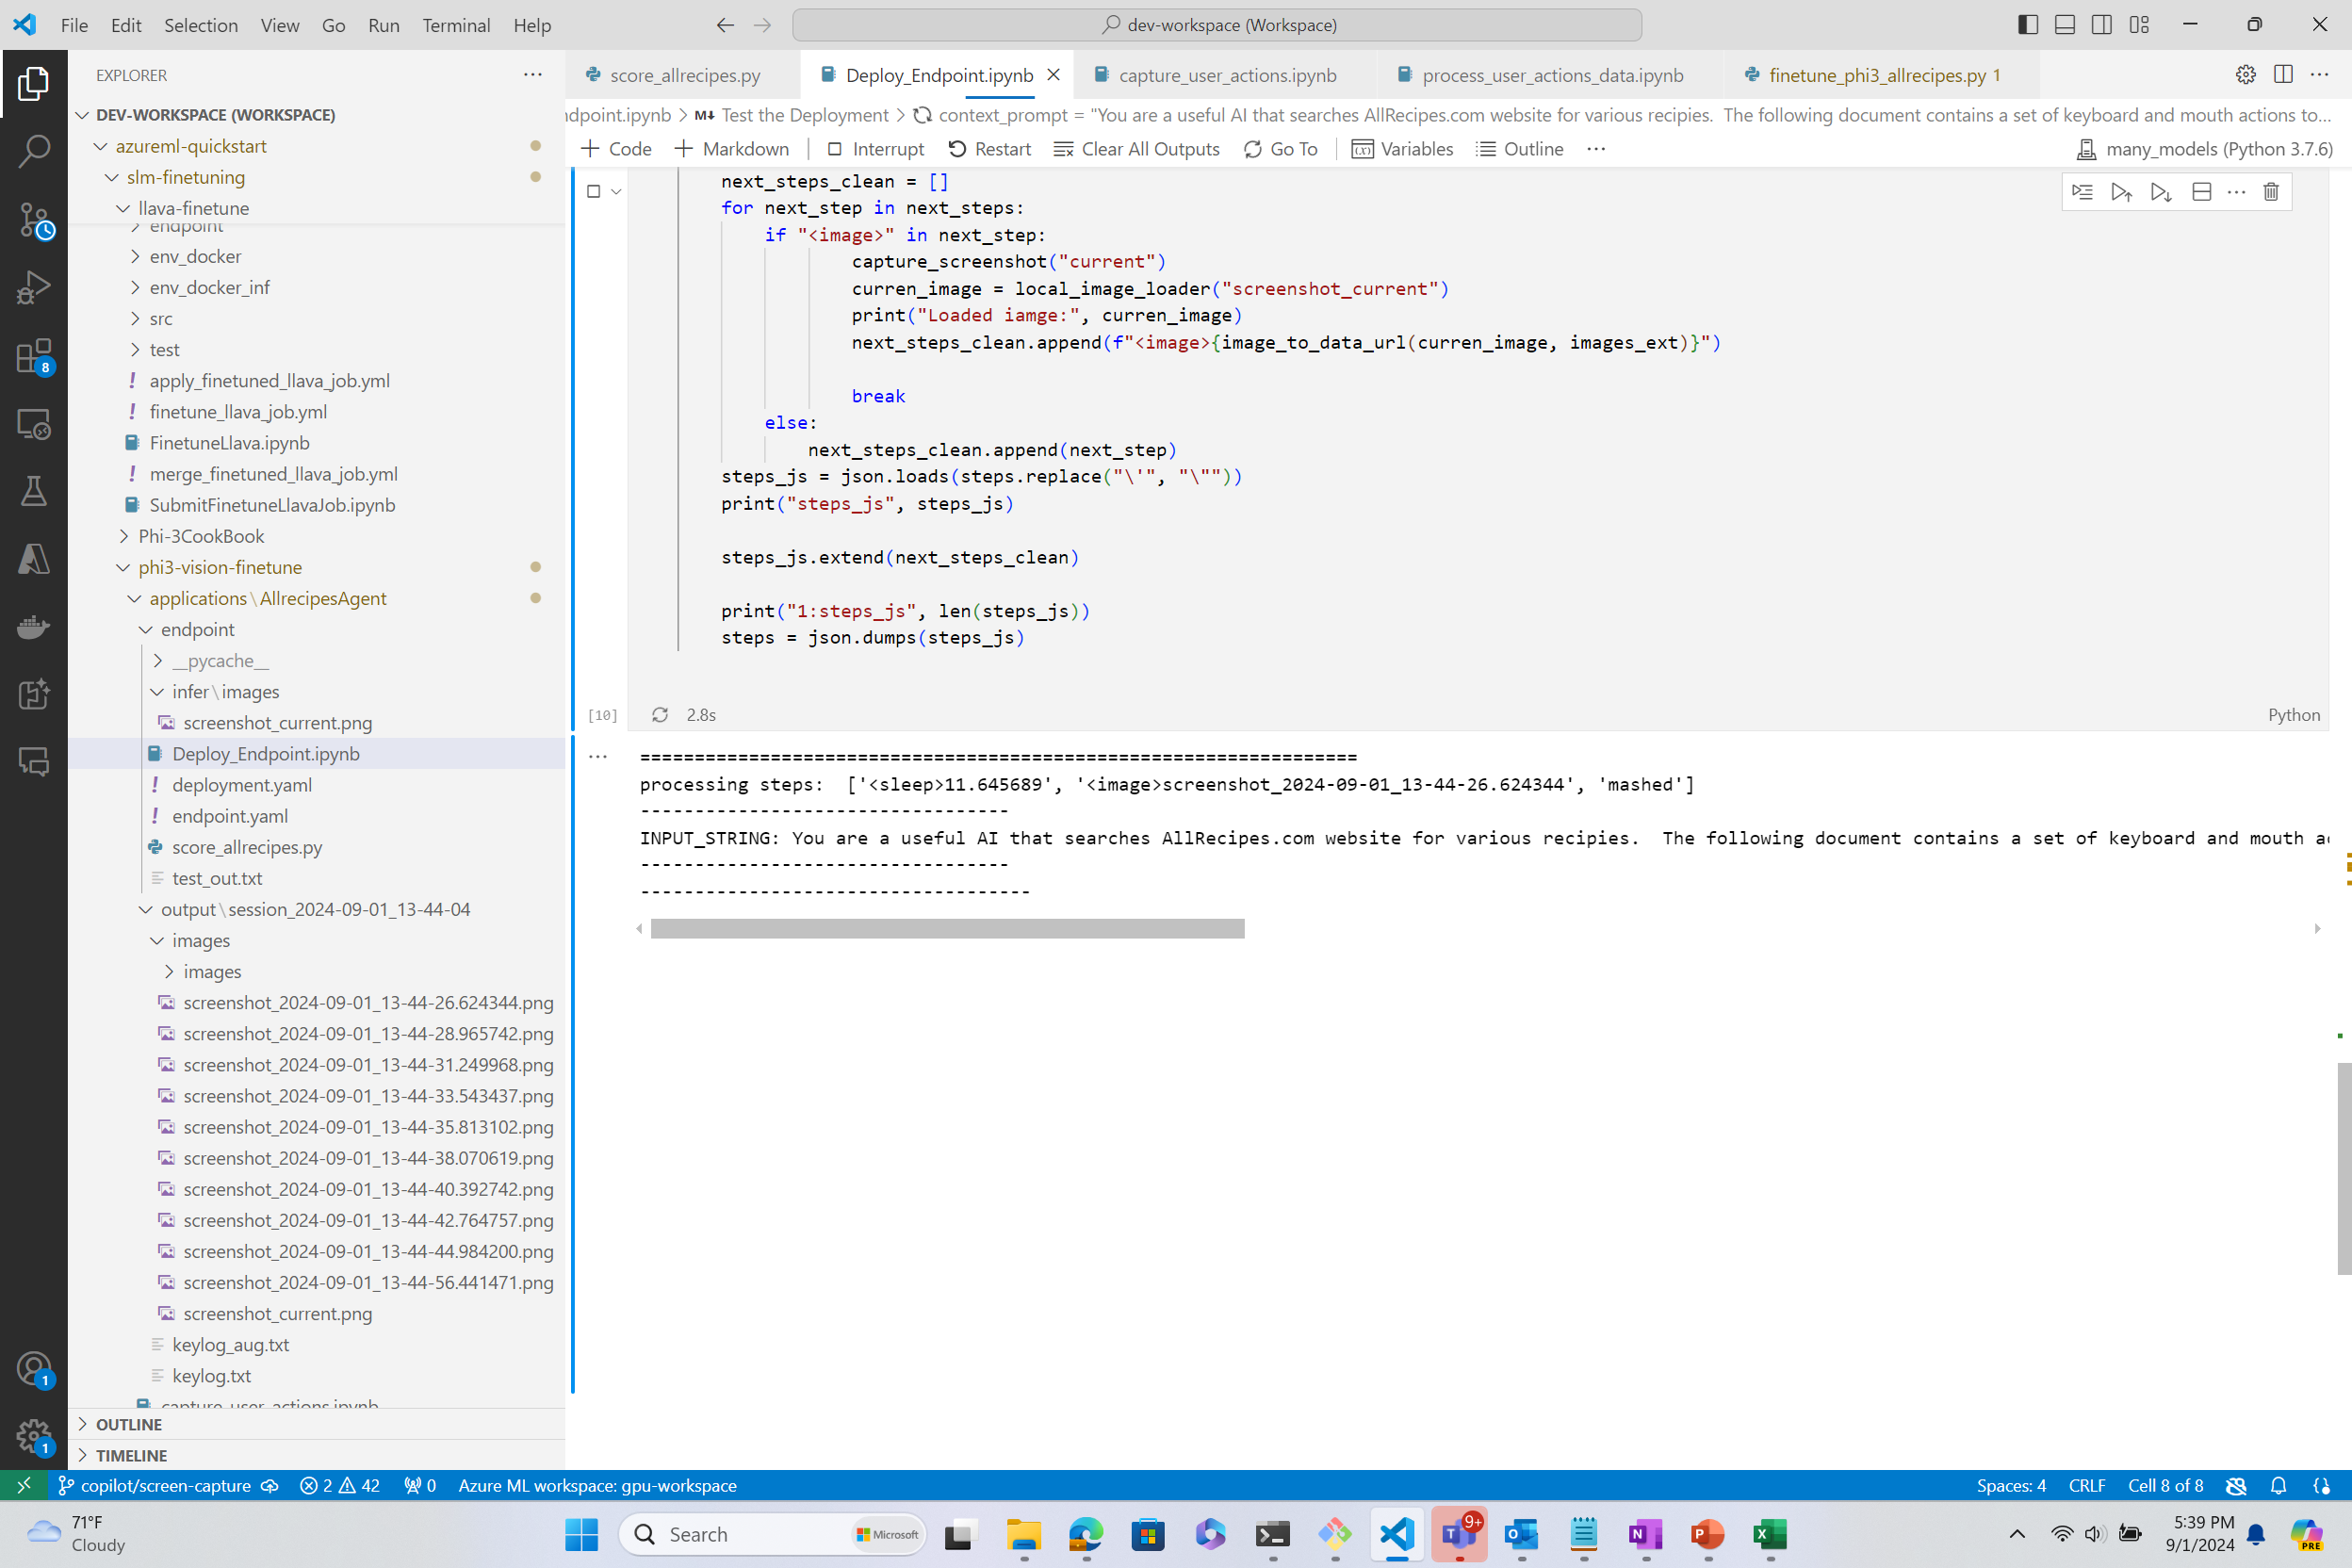

JSONDecodeError: Unterminated string starting at: line 1 column 22 (char 21)

In [10]:
context_prompt = "You are a useful AI that searches AllRecipes.com website for various recipies.  The following document contains a set of keyboard and mouth actions together with the screenshots that preempted them to search for 'mashed potatoes' recipe on the website.  Suggest the nest set of keyboard and mouth actions to continue searching for the recipe."
steps = "['<sleep>11.645689', '<image>screenshot_2024-09-01_13-44-26.624344', 'mashed']"

for i in range(0, 3):
    print("==================================================================")
    print("processing steps: ", steps)
    steps_prompt = f"{context_prompt} {steps}"
    next_steps = test_slm(steps_prompt)
    print("next_steps:", next_steps)
    next_steps_clean = []
    for next_step in next_steps:
        if "<image>" in next_step:
                capture_screenshot("current")
                curren_image = local_image_loader("screenshot_current")
                print("Loaded iamge:", curren_image)
                next_steps_clean.append(f"<image>{image_to_data_url(curren_image, images_ext)}")

                break 
        else:
            next_steps_clean.append(next_step)
    steps_js = json.loads(steps.replace("\'", "\""))
    print("steps_js", steps_js)

    steps_js.extend(next_steps_clean)

    print("1:steps_js", len(steps_js))
    steps = json.dumps(steps_js)
